# Incremental PCA on ImageNet Activations with imgANN

This notebook extracts ImageNet validation activations from an ANN through the local `imgANN` interface and fits `sklearn.decomposition.IncrementalPCA` without loading all activations into memory at once.

## Setup

In [1]:
from pathlib import Path
import gc
import json
import os
import random
import sys
from dataclasses import asdict, dataclass, field
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from sklearn.decomposition import IncrementalPCA
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageNet
from tqdm.auto import tqdm

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])
sys.path.append(paths["src_path"])

from useful_stuff.image_processing.computational_models import imgANN, pool_features
from useful_stuff.image_processing.dim_redu import compute_img_ipca
from useful_stuff.general_utils import get_device, print_wise
from project_specific_utils.dataloader import imagenet_val_dataloader

## Configuration

In [2]:
@dataclass
class Cfg:
    # Model options passed to imgANN.
    model_name: str = "alexnet"
    pkg: str = "torchvision"
    trust_remote_code: bool = False
    image_size: int = 224
    pooling: str = "all"
    n_components: int = 100
    batch_size: int = 100
    
    # default args 
    weights_type: str | None = "DEFAULT"
    repo_url: str | None = "facebook/dinov3-vits16-pretrain-lvd1689m"
    revision: str | None = None
    attn_implementation: str | None = "sdpa"
    dtype: str = "float32"
    

cfg = Cfg()
device = get_device()

## Model Initialization

In [3]:
ann = imgANN(
    model_name=cfg.model_name,
    pkg=cfg.pkg,
    img_size=cfg.image_size,
    pooling=cfg.pooling,  # keep raw activations; postprocess them below in a model-agnostic way.
    weights_type=cfg.weights_type,
    dtype=torch.float32,
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.repo_url,
    revision=cfg.revision,
    trust_remote_code=cfg.trust_remote_code,
)

target_layers = ann.get_relevant_layers()
features_dict, hook_handles = ann.create_forward_hook()
ann

15:04:51 - device being used: mps


ANN(model=alexnet, pkg=torchvision, pooling=all, device=mps, img_size=224)

## Incremental PCA Fitting

In [4]:
dataset, loader = imagenet_val_dataloader(paths, cfg.image_size, cfg.batch_size)

In [ ]:
"""
save_imagenet_val_ipca
Builds the save path for ImageNet validation iPCA components from a model and layer name.
INPUT:
    - paths: dict -> config paths dictionary containing the data root path
    - model_name: str -> ANN model name used to compute activations
    - layer_name: str -> ANN layer name used to compute activations
    - n_components: int -> number of iPCA components saved in the file

OUTPUT:
    - save_path: Path -> path where the ImageNet validation iPCA object is saved
"""
def save_imagenet_val_ipca(paths, model_name, layer_name, n_components):
    save_dir = Path(paths["data_path"]) / "models" / "imagenet_components"
    file_name = f"{model_name}_{layer_name}_imagenet_val_{n_components}components.pkl"
    save_path = save_dir / file_name
    return save_path
# EOF


"""
ipca_imagenet_wrapper
Fits and saves ImageNet validation iPCA objects for target layers that have not been computed yet.
INPUT:
    - ann: imgANN -> model wrapper used to extract target-layer activations
    - loader: DataLoader -> ImageNet validation image batches
    - target_layers: list[str] -> ANN layer names where activations are extracted
    - n_components: int -> number of iPCA components to fit for each layer
    - batch_size: int -> iPCA batch size used for each IncrementalPCA object

OUTPUT:
    - ipcas: dict[str, IncrementalPCA] -> newly fitted iPCA objects keyed by layer name
"""
def ipca_imagenet_wrapper(ann, loader, target_layers, n_components, batch_size):
    # Build all expected output paths and keep only layers whose files do not exist yet.
    save_paths = {
        layer: save_imagenet_val_ipca(paths, ann.model_name, layer, n_components)
        for layer in target_layers
    }
    missing_layers = [layer for layer in target_layers if not save_paths[layer].exists()]
    existing_layers = [layer for layer in target_layers if save_paths[layer].exists()]

    if existing_layers:
        print_wise(f"Skipping existing {ann.model_name} layers: {', '.join(existing_layers)}")
    if not missing_layers:
        print_wise(f"All requested {ann.model_name} iPCA files already exist; skipping iPCA.")
        return {}

    # Register hooks only for layers that still need to be computed.
    ann.features = {}
    ann.create_forward_hook(missing_layers)

    # Create one iPCA object per missing layer, capped by that layer's feature dimensionality.
    ipcas = {
        layer: IncrementalPCA(
            n_components=min(n_components, np.prod(ann.get_layer_output_shape(layer))),
            batch_size=batch_size,
        )
        for layer in missing_layers
    }

    # Fit iPCA objects by streaming ImageNet validation activations batch by batch.
    ipcas = compute_img_ipca(ann, loader, ipcas, device)

    # Save only the newly fitted layer-specific iPCA objects.
    for layer in missing_layers:
        save_paths[layer].parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(ipcas[layer], save_paths[layer])
    return ipcas
# EOF


In [12]:
save_imagenet_val_ipca(paths, cfg.model_name, target_layers[0], cfg.n_components)

PosixPath('/Users/tizianocausin/sd_local/models/imagenet_components/alexnet_features.0_imagenet_val_100components.pkl')

In [ ]:
"""
save_imagenet_val_ipca
Builds the save path for ImageNet validation iPCA components from a model and layer name.
INPUT:
    - paths: dict -> config paths dictionary containing the data root path
    - model_name: str -> ANN model name used to compute activations
    - layer_name: str -> ANN layer name used to compute activations
    - n_components: int -> number of iPCA components saved in the file

OUTPUT:
    - save_path: Path -> path where the ImageNet validation iPCA object is saved
"""
def save_imagenet_val_ipca(paths, model_name, layer_name, n_components):
    save_dir = Path(paths["data_path"]) / "models" / "imagenet_components"
    file_name = f"{model_name}_{layer_name}_imagenet_val_{n_components}components.pkl"
    save_path = save_dir / file_name
    return save_path
# EOF


"""
ipca_imagenet_wrapper
Fits and saves ImageNet validation iPCA objects for target layers that have not been computed yet.
INPUT:
    - ann: imgANN -> model wrapper used to extract target-layer activations
    - loader: DataLoader -> ImageNet validation image batches
    - target_layers: list[str] -> ANN layer names where activations are extracted
    - n_components: int -> number of iPCA components to fit for each layer
    - batch_size: int -> iPCA batch size used for each IncrementalPCA object

OUTPUT:
    - ipcas: dict[str, IncrementalPCA] -> newly fitted iPCA objects keyed by layer name
"""
def ipca_imagenet_wrapper(ann, loader, target_layers, n_components, batch_size):
    # Build all expected output paths and keep only layers whose files do not exist yet.
    save_paths = {
        layer: save_imagenet_val_ipca(paths, ann.model_name, layer, n_components)
        for layer in target_layers
    }
    missing_layers = [layer for layer in target_layers if not save_paths[layer].exists()]
    existing_layers = [layer for layer in target_layers if save_paths[layer].exists()]

    if existing_layers:
        print_wise(f"Skipping existing {ann.model_name} layers: {', '.join(existing_layers)}")
    if not missing_layers:
        print_wise(f"All requested {ann.model_name} iPCA files already exist; skipping iPCA.")
        return {}

    # Register hooks only for layers that still need to be computed.
    ann.features = {}
    ann.create_forward_hook(missing_layers)

    # Create one iPCA object per missing layer, capped by that layer's feature dimensionality.
    ipcas = {
        layer: IncrementalPCA(
            n_components=min(n_components, np.prod(ann.get_layer_output_shape(layer))),
            batch_size=batch_size,
        )
        for layer in missing_layers
    }

    # Fit iPCA objects by streaming ImageNet validation activations batch by batch.
    ipcas = compute_img_ipca(ann, loader, ipcas, device)

    # Save only the newly fitted layer-specific iPCA objects.
    for layer in missing_layers:
        save_paths[layer].parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(ipcas[layer], save_paths[layer])
    return ipcas
# EOF


Projecting random images:   0%|          | 0/2 [00:03<?, ?it/s]

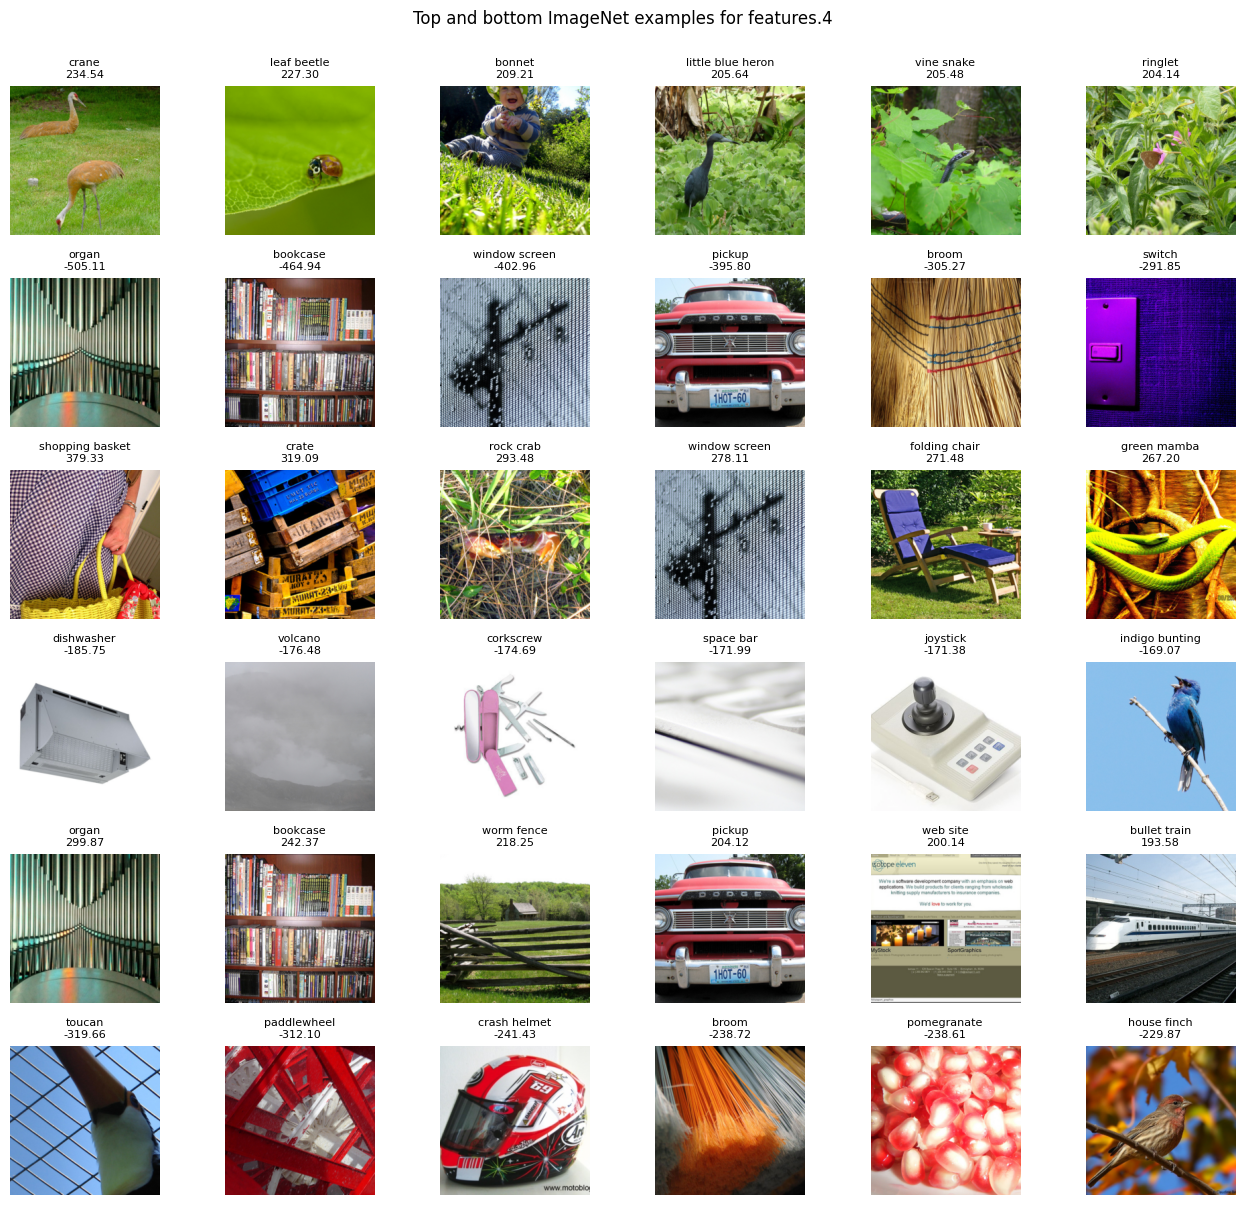

In [7]:
sample_n = 1024
n_extreme = 6
n_pcs_to_show = 3
layer = cfg.target_layers[1]

rng = np.random.default_rng(cfg.seed+100)
viz_indices = rng.choice(len(dataset), size=min(sample_n, len(dataset)), replace=False).tolist()
viz_dataset = Subset(dataset, viz_indices)
viz_loader = DataLoader(
    viz_dataset,
    batch_size=cfg.batch_size*10,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory and torch.cuda.is_available(),
    persistent_workers=cfg.num_workers > 0,
)

viz_images = []
viz_targets = []
viz_features = []

ann.get_model().eval()
for images, targets in tqdm(viz_loader, desc="Projecting random images"):
    viz_images.append(images.cpu())
    viz_targets.append(targets.cpu())

    images = images.to(device, non_blocking=True)
    with torch.inference_mode():
        if cfg.pkg == "hf":
            ann.model(pixel_values=images)
        else:
            ann.model(images)

    features = ann.features[layer].detach().float().cpu().numpy()
    viz_features.append(features)

viz_images = torch.cat(viz_images)
viz_targets = torch.cat(viz_targets)
viz_features = np.concatenate(viz_features, axis=0)
viz_scores = ipcas[layer].transform(viz_features)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
classes = dataset.dataset.classes if isinstance(dataset, Subset) else dataset.classes

def show_image(ax, image, target, score):
    image = (image * std + mean).clamp(0, 1)
    class_names = classes[int(target)]
    label = class_names[0] if isinstance(class_names, tuple) else class_names
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"{label}\n{score:.2f}", fontsize=8)
    ax.axis("off")

n_pcs_to_show = min(n_pcs_to_show, viz_scores.shape[1])
fig, axes = plt.subplots(n_pcs_to_show * 2, n_extreme, figsize=(2.2 * n_extreme, 4.0 * n_pcs_to_show))
axes = np.atleast_2d(axes)

for pc_idx in range(n_pcs_to_show):
    scores = viz_scores[:, pc_idx]
    bottom_indices = np.argsort(scores)[:n_extreme]
    top_indices = np.argsort(scores)[-n_extreme:][::-1]

    axes[2 * pc_idx, 0].set_ylabel(f"PC {pc_idx + 1} top", fontsize=10)
    axes[2 * pc_idx + 1, 0].set_ylabel(f"PC {pc_idx + 1} bottom", fontsize=10)

    for col, idx in enumerate(top_indices):
        show_image(axes[2 * pc_idx, col], viz_images[idx], viz_targets[idx], scores[idx])
    for col, idx in enumerate(bottom_indices):
        show_image(axes[2 * pc_idx + 1, col], viz_images[idx], viz_targets[idx], scores[idx])

fig.suptitle(f"Top and bottom ImageNet examples for {layer}", y=1.0)
plt.tight_layout()
plt.show()